# ALL METHODS PLOTS

This notebook makes plots of a collection of settings, namely 

- community detection algorithms for test
- budget factor
- similarity threshold

and combine the results for a collection of datasets, evasion methods and metrics.

## Imports
 

In [1]:
from typing import List
from enum import Enum
import seaborn as sns
import os
import pandas as pd
import json
from statistics import mean
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

## Objects from utils file


In [3]:
class DatasetNames(Enum):
    """Enum class for the dataset names"""

    KAR = "kar"
    WORDS = "words"
    VOTE = "vote"
    POW = "pow"
    FB_75 = "fb-75"
    COND_MAT = "cond-mat"
   
class DetectionAlgorithmsNames(Enum):
    """Enum class for the detection algorithms"""
    
    GRE = "greedy"
    LOUV = "louvain"
    WALK = "walktrap"
    LEID = "leiden"
    INF = "infomap"
    LAB = "label_propagation"
    EIG = "leading_eigenvector"
    BTW = "edge_betweenness"
    SPIN = "spinglass"
    SCD = "scd"
    LOC = "locale"
    DGC = "dgcluster"

class EvasionAlgorithmsNames(Enum):
    RAND = "random"
    DEG = "degree"
    BETW = "betweenness"
    ROAM = "roam"
    DICE = "dice"
    NABLA = "nabla-cmh"
    NABLAP = "nabla-cmh-projected"
    DRL = "drl-agent"
    GRE = "greedy"

def check_dir(path: str):
        """
        Check if the directory exists, if not create it.

        Parameters
        ----------
        path : str
            Path to the directory
        """
        if not os.path.exists(path):
            os.makedirs(path)

## Configuration

In [5]:
evasion_algs = ["RAND", "DEG", "BETW", "ROAM", "DICE", "NABLA", "NABLAP", "DRL"]

datasets = ["KAR", "WORDS", "VOTE", "POW", "FB_75", "COND_MAT"]

detection_algs = ["GRE", "LOUV", "LEID", "WALK", "INF", "LAB", "SCD", "LOC", "DGC"]
#detection_algs = ["GRE"]

budget_factors = [0.5,1,2]
#budget_factors = [1]

taus = [0.5]

results_dir = "../outputs_review/runs"
outputs_dir = "../outputs_review"
save_dir = "../outputs_review/all_datasets"

seeds = [22,2025,42]

### Directory check

In [6]:
for seed in seeds:
    for dataset in datasets:
        for alg in detection_algs:
            for tau in taus:
                for c_beta in budget_factors:
                    dataset_name = getattr(DatasetNames, dataset).value
                    alg_name = getattr(DetectionAlgorithmsNames, alg).value
                    check_dir(results_dir + f"/seed_{seed}/{dataset_name}/{alg_name}/tau_{tau}/betaFactor_{c_beta}/plots/")  

## F1 Plot


In [18]:
def plot_f1_all_datasets(
    datasets: List[str], 
    detection_algs: List[str],
    seeds: List[int],
    taus: List[float],
    betas: List[float]
    ):
    """
    Plot the f1 scores of the evaluation on all the datasets and detection algorithms across all runs.
    The f1 scores are calculated as the harmonic mean of the goal and nmi scores.

    Parameters
    ----------
    datasets : List[str]
        List of datasets
    detection_algs : List[str]
        List of detection algorithms
    seeds : List[int]
        List of seeds
    taus : List[float]
        List of tau values
    betas : List[float]
        List of beta values
    """


    save_path = "../outputs_review/all_datasets/f1_score/"
    check_dir(save_path)

    dataset_names = [getattr(DatasetNames, dataset).value for dataset in datasets]
    evading_algs=["NABLA","NABLAP", "DRL","RAND","DICE","DEG","ROAM","BETW"]
    community_algs = [getattr(DetectionAlgorithmsNames, alg).value for alg in detection_algs]

    # Redefine the names of the algorithms
    nabla_renamed = r"$\nabla$-CMH (ours)"
    nablap_renamed = r"$\nabla$-CMH-P"
    agent_renamed = "DRL-Agent"
    random_renamed = "Random"
    dice_renamed = "DICE"
    deg_renamed = "Degree"
    roam_renamed = "ROAM"
    betweenness_renamed = "Centrality"

    f1_dict = {}
    for dataset in dataset_names:
        f1_dict[dataset] = {}
        for detection_alg in community_algs:
            f1_dict[dataset][detection_alg] = {}
            for tau in taus:
                f1_dict[dataset][detection_alg][f"tau_{tau}"] = {}
                for beta in betas:
                    f1_dict[dataset][detection_alg][f"tau_{tau}"][f"beta_{beta}"] = {}
                    for alg in evading_algs:
                        f1_dict[dataset][detection_alg][f"tau_{tau}"][f"beta_{beta}"][alg] = []
                        for seed in seeds:
                            json_path = f"{results_dir}/seed_{seed}/{dataset}/{detection_alg}/tau_{tau}/betaFactor_{beta}/plots/metrics.json"
                            with open(json_path, "r") as f:
                                log = json.load(f)
                            f1_dict[dataset][detection_alg][f"tau_{tau}"][f"beta_{beta}"][alg].append(log["f1"][alg])


    for detection_alg in community_algs:
        for tau in taus:
            for beta in betas:
                plot_data = []
                for dataset in dataset_names:
                    df = pd.DataFrame(f1_dict[dataset][detection_alg][f"tau_{tau}"][f"beta_{beta}"])
                    plot_data.append(df)
                df = pd.concat(plot_data,axis=1)
                # Replace algorithm names in evading_algs list
                evading_algs = [
                    nabla_renamed,
                    nablap_renamed,
                    agent_renamed,
                    random_renamed,
                    dice_renamed,
                    deg_renamed,
                    roam_renamed,
                    betweenness_renamed
                ]
                # in datasets list replace "cond-mat" with "arxiv"
                datasets_renamed = ["arxiv" if dataset == "cond-mat" else dataset for dataset in dataset_names]
                df.columns = pd.MultiIndex.from_product([datasets_renamed, evading_algs])
                # Melt the dataframe
                df = df.melt(var_name=["Dataset", "Algorithm"], value_name="f1")
                max_value = df.groupby(['Dataset', 'Algorithm'])["f1"].mean().max()

                # Palette personalizzata 1
                custom_palette1 = {
                    nabla_renamed: "#0141FF",  
                    agent_renamed: "#4B4D52",  
                    random_renamed: "#4572F5",       
                    dice_renamed: "#7F879E",     
                    deg_renamed: "#B40F00",        
                    roam_renamed: "#CBCAC8",    
                    betweenness_renamed: "#8F00A2"   
                }

                # Palette personalizzata 2
                custom_palette2 = {
                    nabla_renamed: "#1019C7",
                    nablap_renamed: "#1019C7",
                    agent_renamed: "#0AAEC3", 
                    dice_renamed: "#018E20",  
                    roam_renamed: "#96AD11",  
                    random_renamed: "#DE8D00",         
                    deg_renamed: "#B40F00",              
                    betweenness_renamed: "#8F00A2"   
                }

                sns.set_theme(style="whitegrid")
                #plt.rcParams['text.usetex'] = False  
                g = sns.catplot(
                    data=df,
                    kind="bar",
                    x="Dataset",
                    y="f1",
                    hue="Algorithm",
                    hue_order=[
                        r"$\nabla$-CMH (ours)", 
                        r"$\nabla$-CMH-P",
                        "DRL-Agent", 
                        "DICE", 
                        "ROAM",
                        "Random", 
                        "Degree", 
                        "Centrality", 
                    ],
                    aspect=2,
                    palette=custom_palette2,
                    errorbar=('ci', 95),
                    legend=False,
                    capsize=0.3,
                    err_kws={
                        'linewidth': .9,   
                        'color': 'black',    
                    },
                )
                ax = g.ax  
                ax.set_yticks([i * 0.1 for i in range(0, 11)])
                g.set_axis_labels("Datasets", "F1 score", fontsize=25)
                g.set_yticklabels(fontsize=20)
                g.set_xticklabels(ha="center", fontsize=25)
                custom_handles = [
                    Patch(facecolor=custom_palette2[alg], label=alg, 
                        hatch=('//' if alg == '$\\nabla$-CMH (ours)' else 
                                '...' if alg == '$\\nabla$-CMH-P' else ''))
                    for alg in ['$\\nabla$-CMH (ours)', 'Random', '$\\nabla$-CMH-P', 'Degree', 'DRL-Agent', 'Centrality', 'DICE', 'ROAM']
                ]
                plt.legend(handles=custom_handles, loc='upper center', bbox_to_anchor=(0.47, 1.3), frameon=False, ncol=4, fontsize=20)
                for ax in g.axes.flat:
                    ax.spines["top"].set_visible(True)
                    ax.spines["right"].set_visible(True)
                    ax.spines["top"].set_color("black")
                    ax.spines["right"].set_color("black")
                    ax.spines["left"].set_color("black")
                    ax.spines["bottom"].set_color("black")
                indices_to_hatch_lines = [0,1,2,3,4,5]
                indices_to_hatch_reversed = [6,7,8,9,10,11] 
                #indices_to_hatch_lines = [0,1,2,3] 
                for ax in g.axes.flat:  
                    bars = ax.patches  
                    bars = [bar for bar in ax.patches if bar.get_height() > 0]
                    for i, bar in enumerate(bars):  
                        if i in indices_to_hatch_lines:  
                            bar.set_hatch('//')  
                        elif i in indices_to_hatch_reversed:
                            bar.set_hatch('...')


                save_fig_path = f"{save_path}/{detection_alg}/tau_{tau}/beta_{beta}"
                check_dir(save_fig_path)
                g.savefig(
                    f"{save_fig_path}/f1_score_grouped.pdf",
                    bbox_inches="tight",
                    dpi=1000,
                )

## F1 Plot Function call

/home/hl-fury/miniconda3/envs/graph-cmh/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/home/hl-fury/miniconda3/envs/graph-cmh/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/home/hl-fury/miniconda3/envs/graph-cmh/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/home/hl-fury/miniconda3/envs/graph-cmh/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/home/hl-fury/miniconda3/envs/graph-cmh/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/home/hl-fury/miniconda3/envs/graph-cmh/lib/python

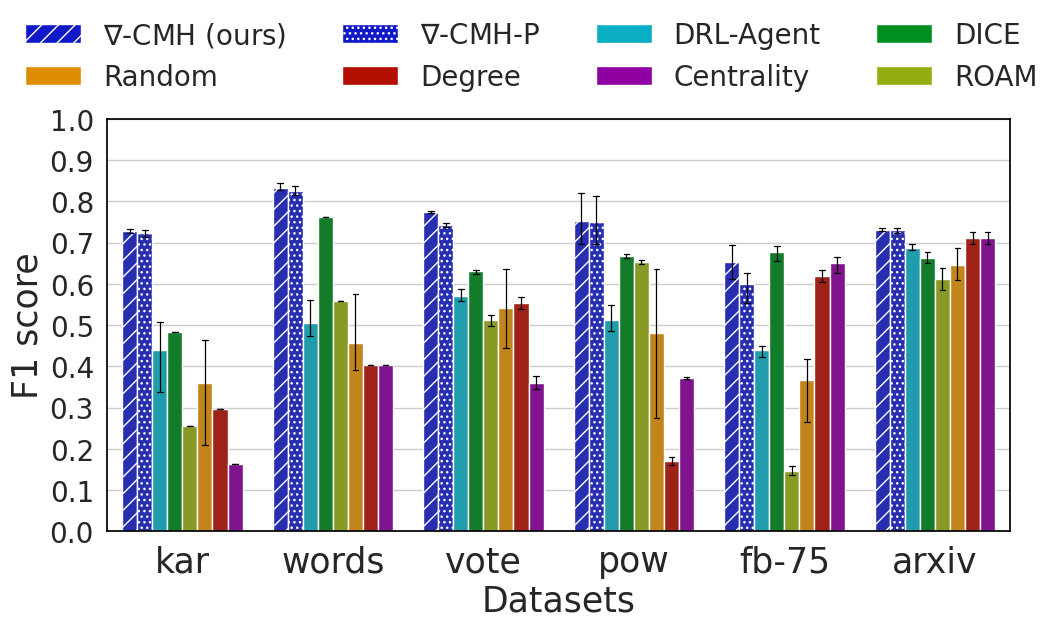

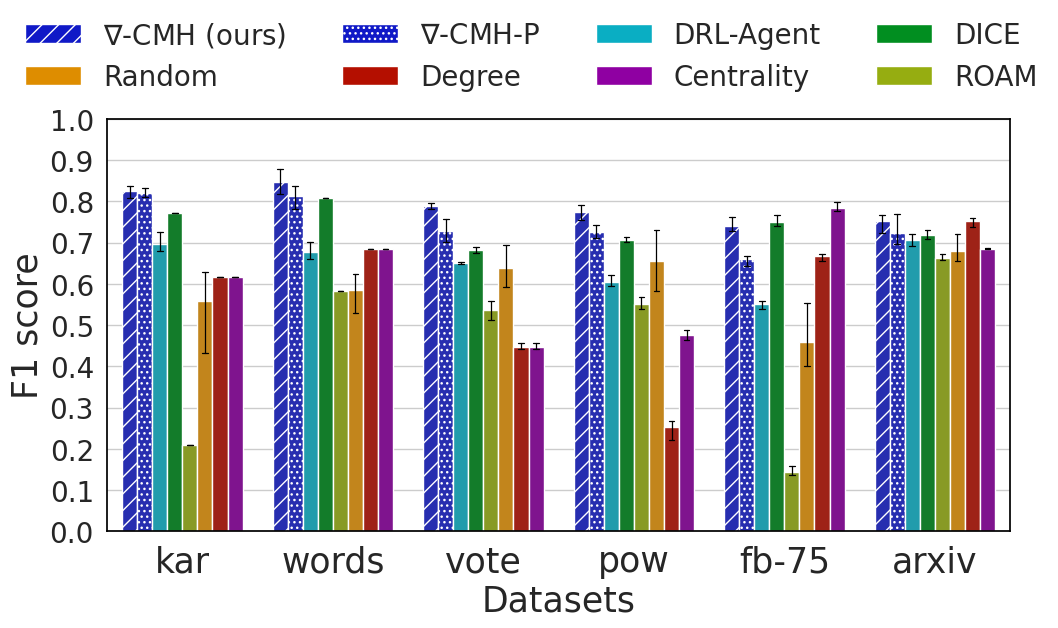

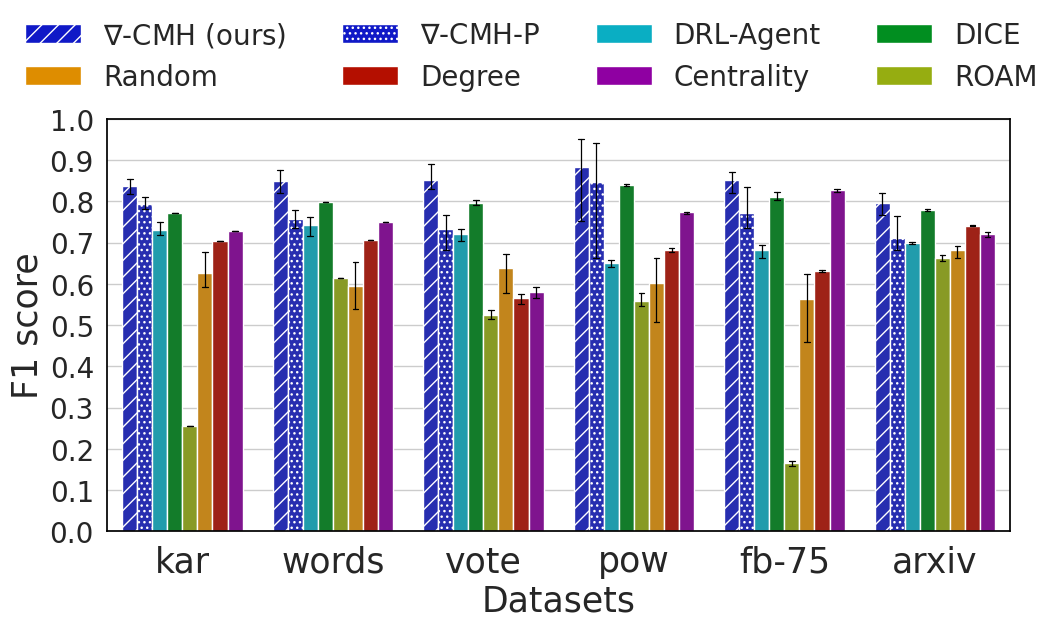

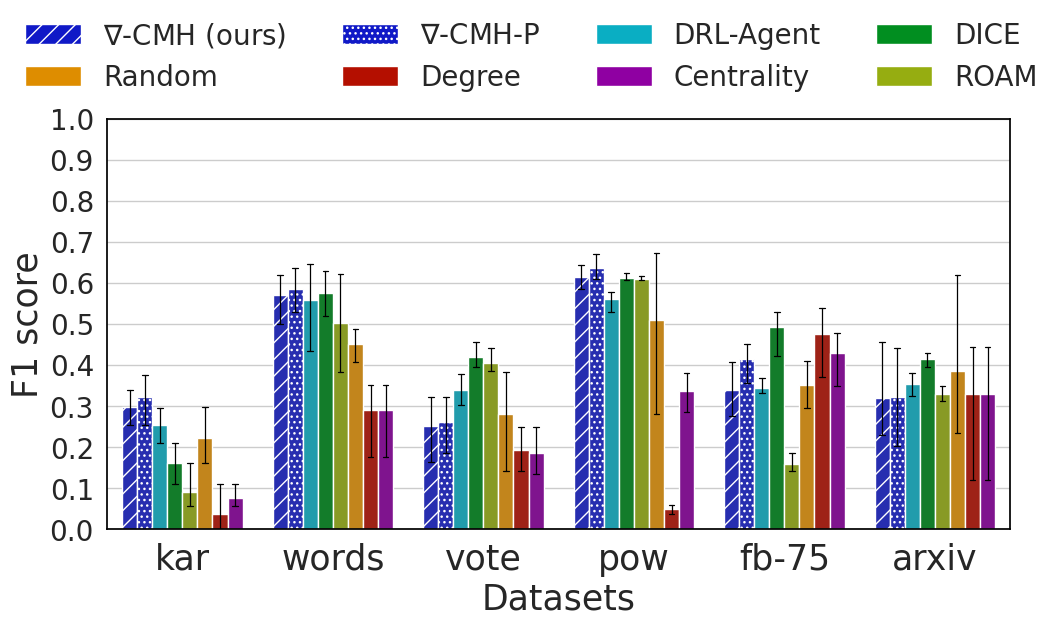

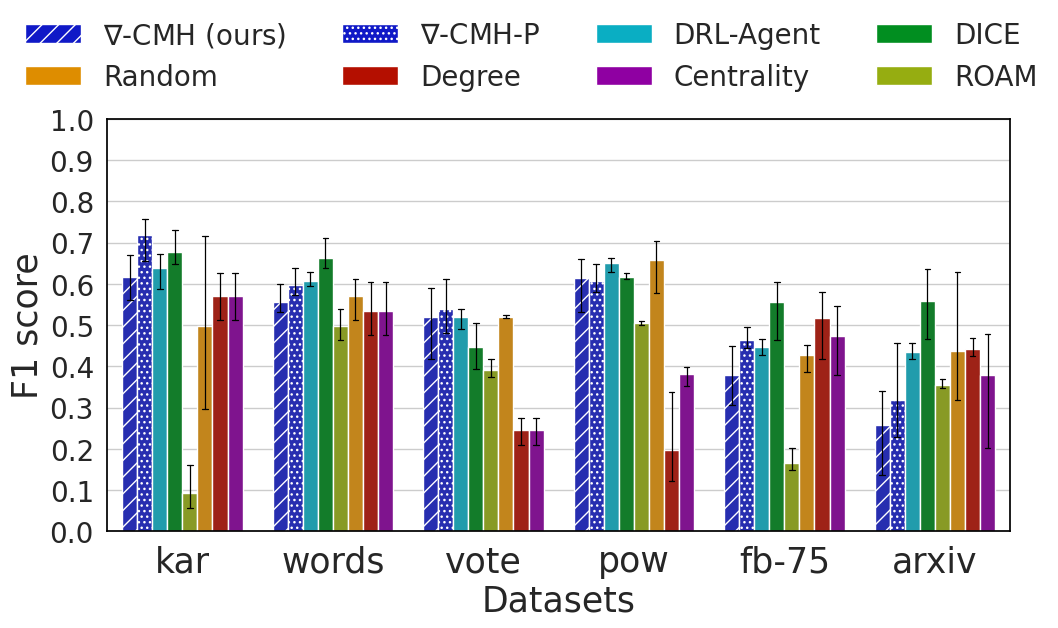

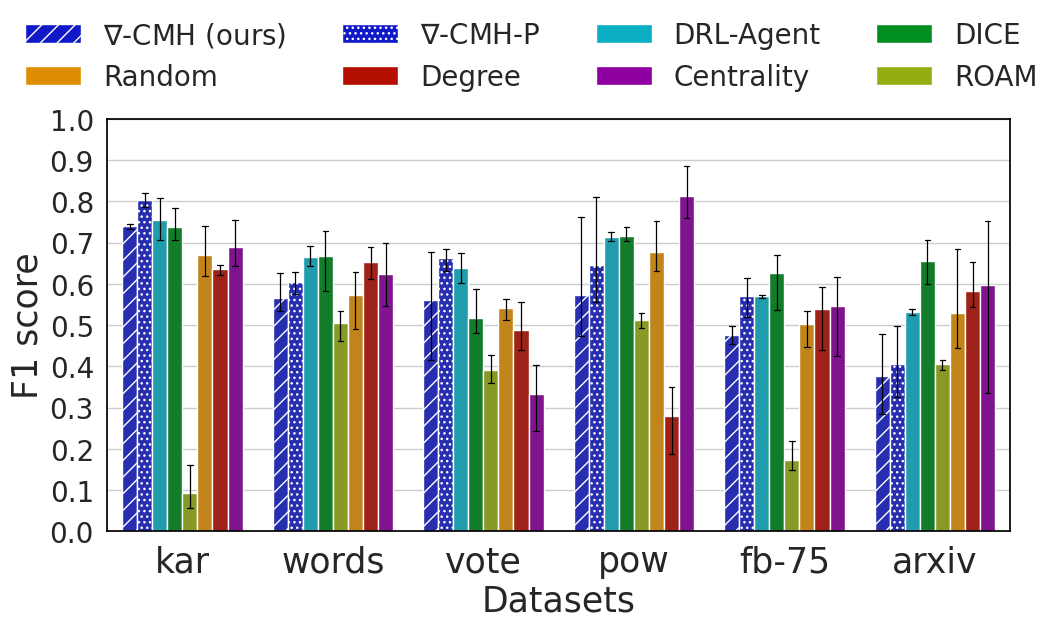

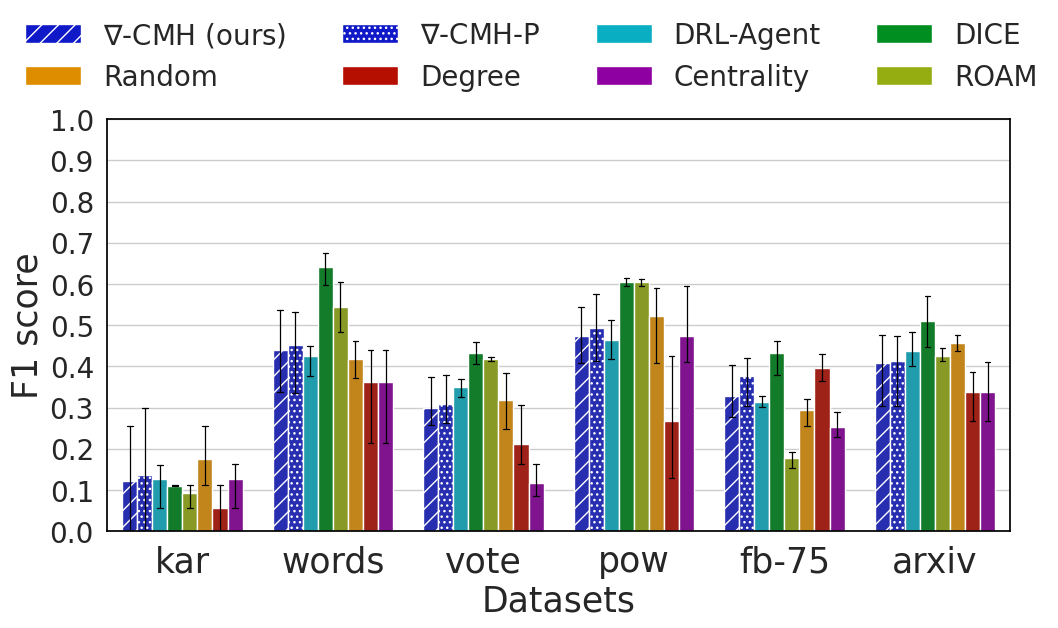

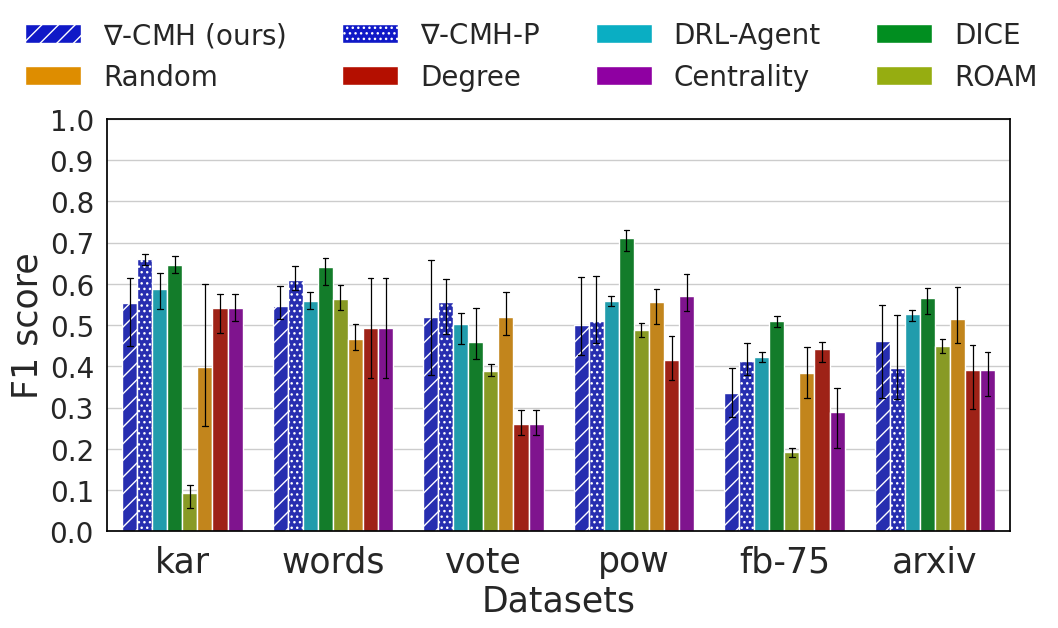

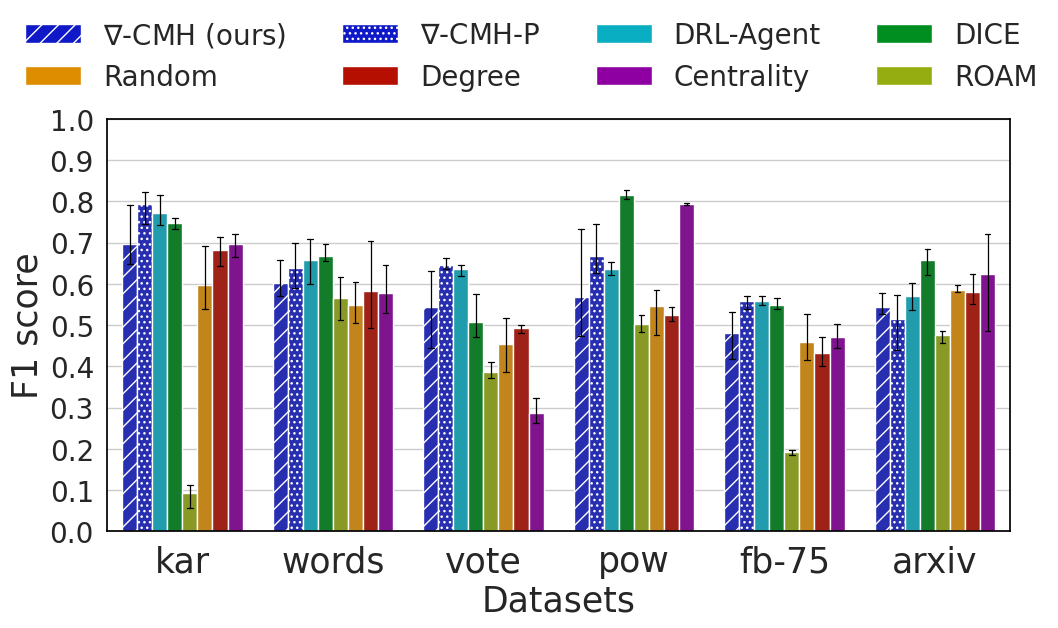

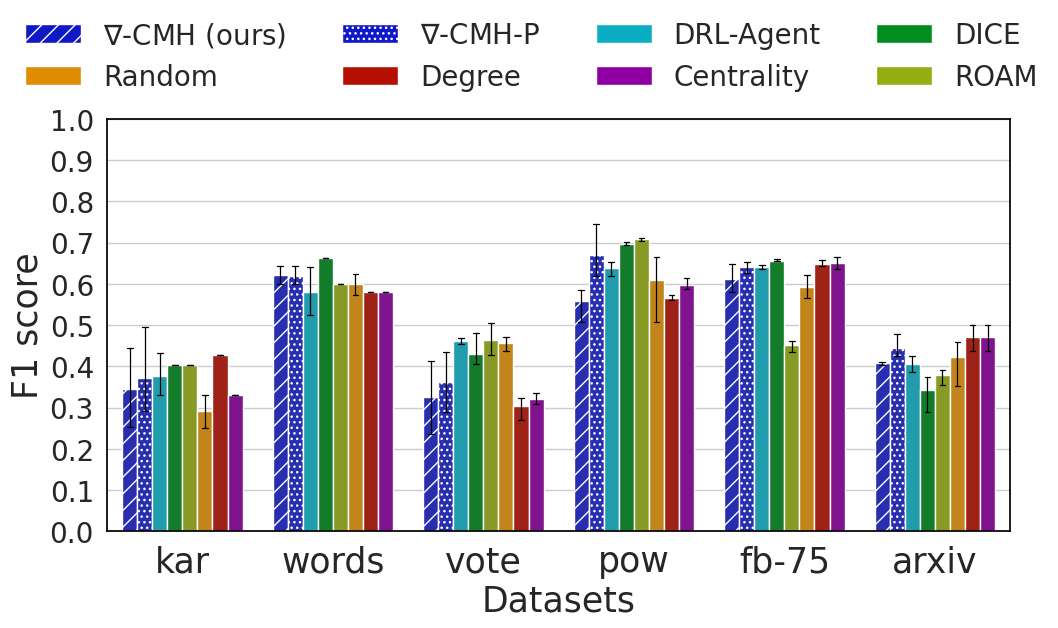

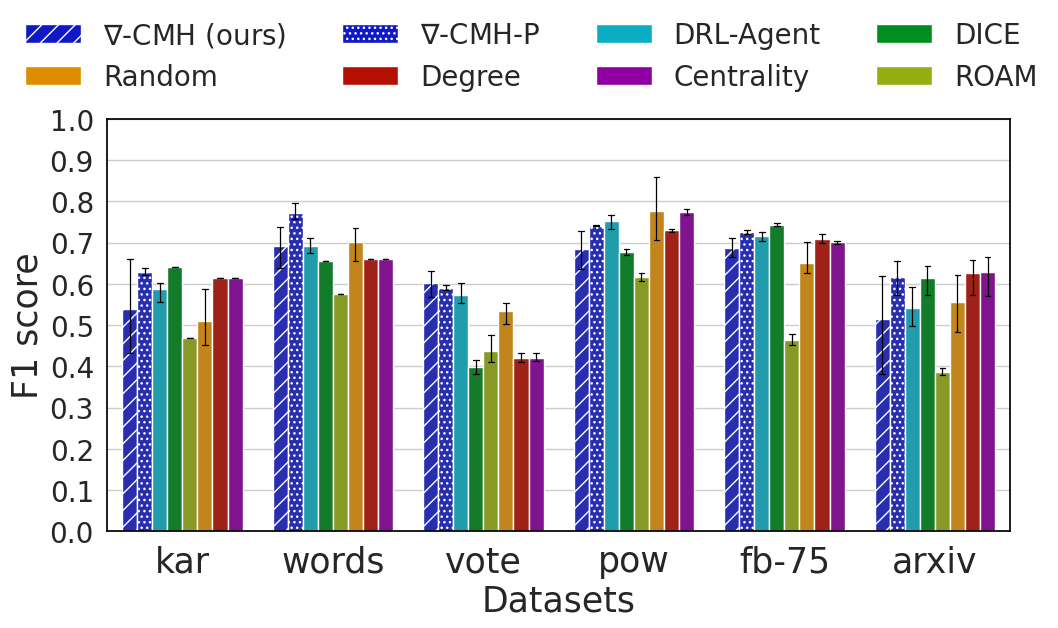

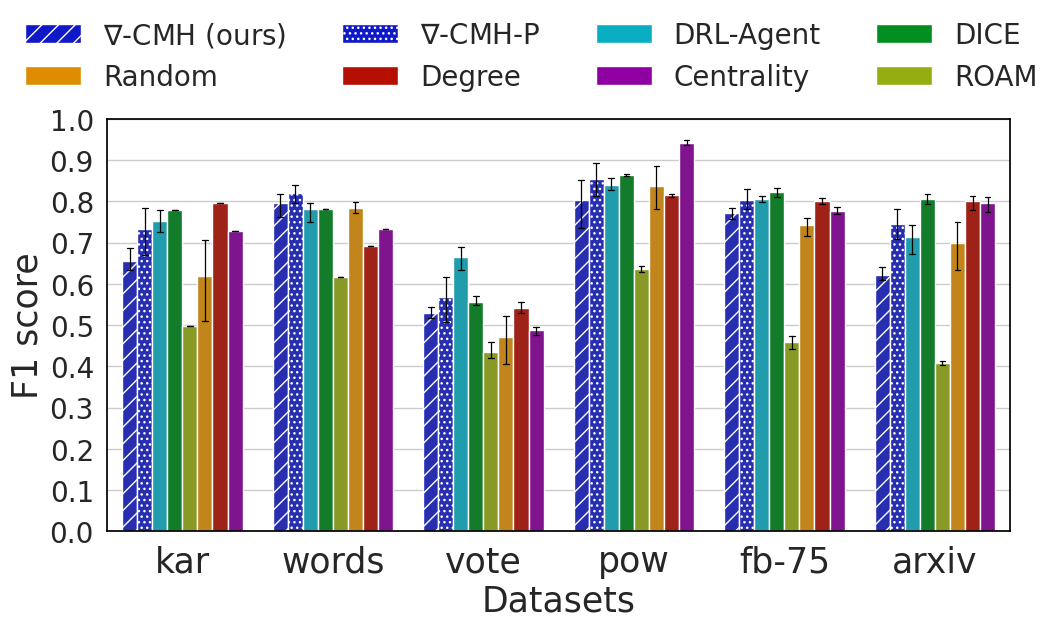

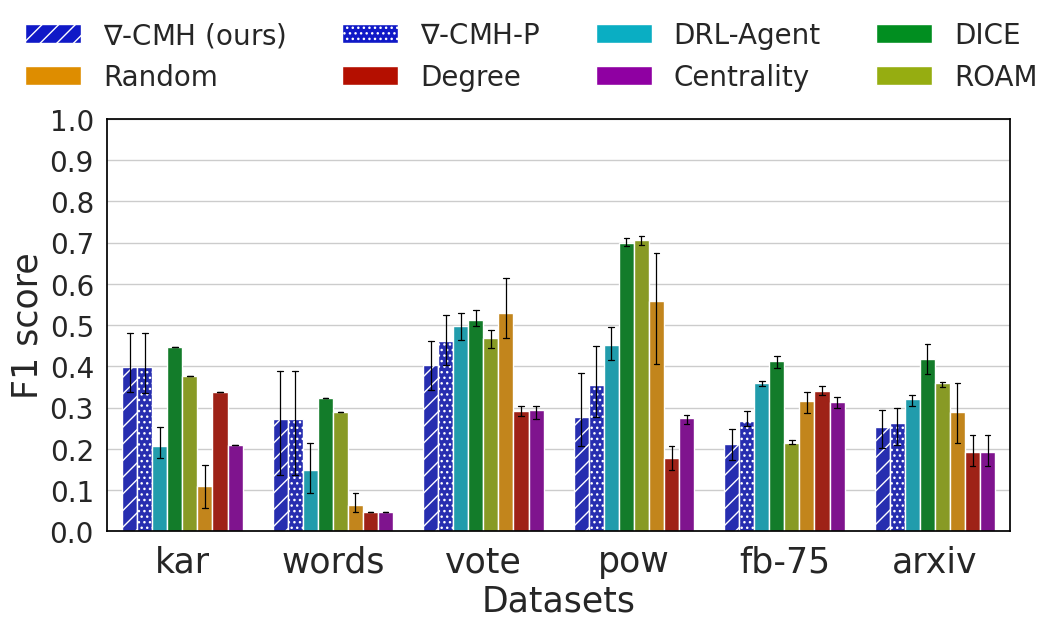

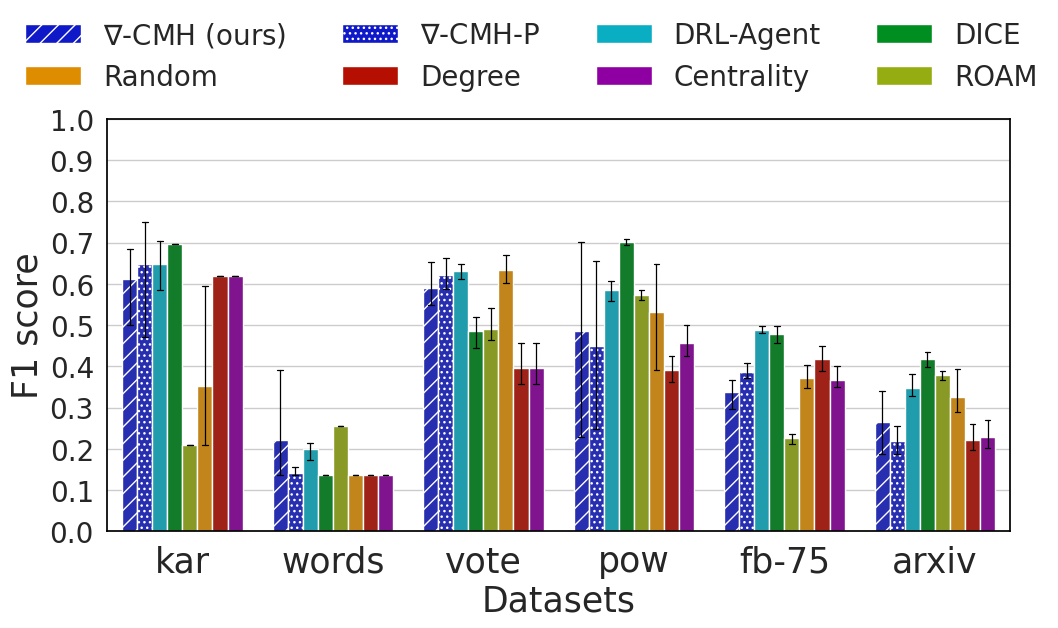

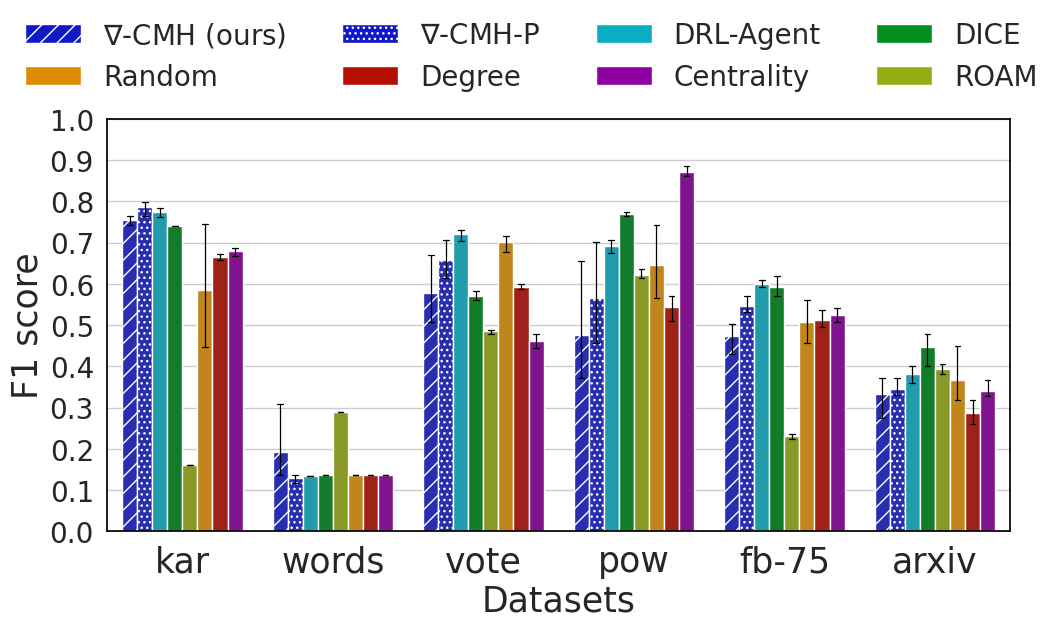

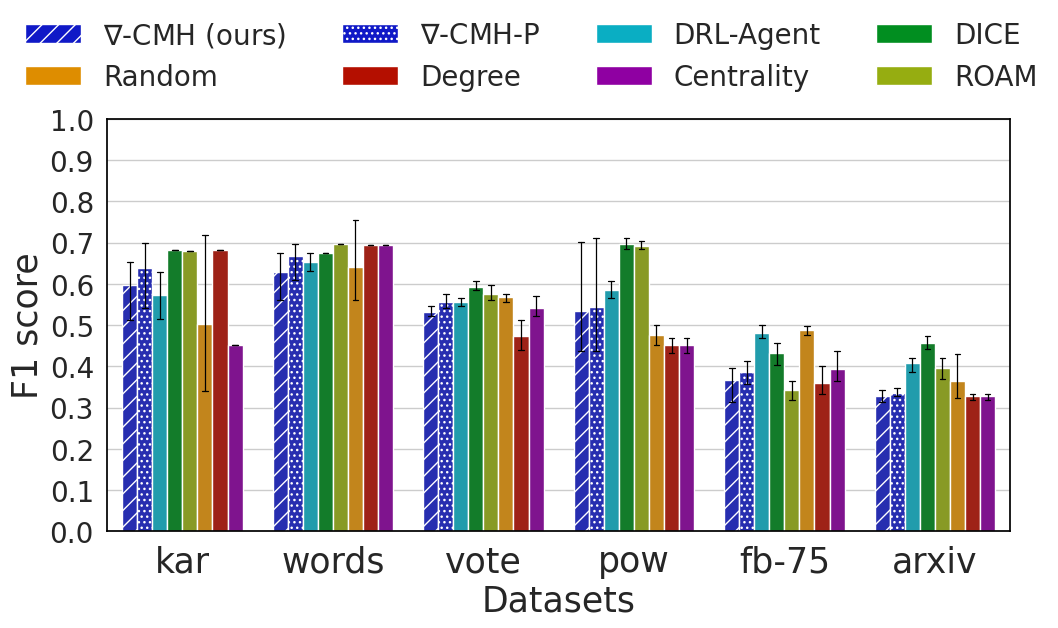

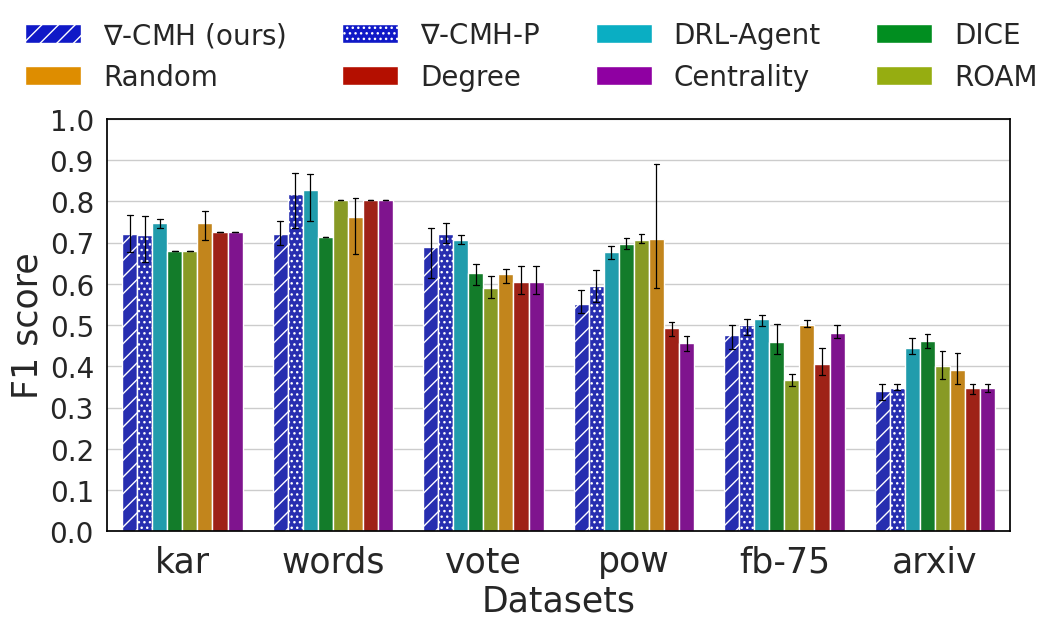

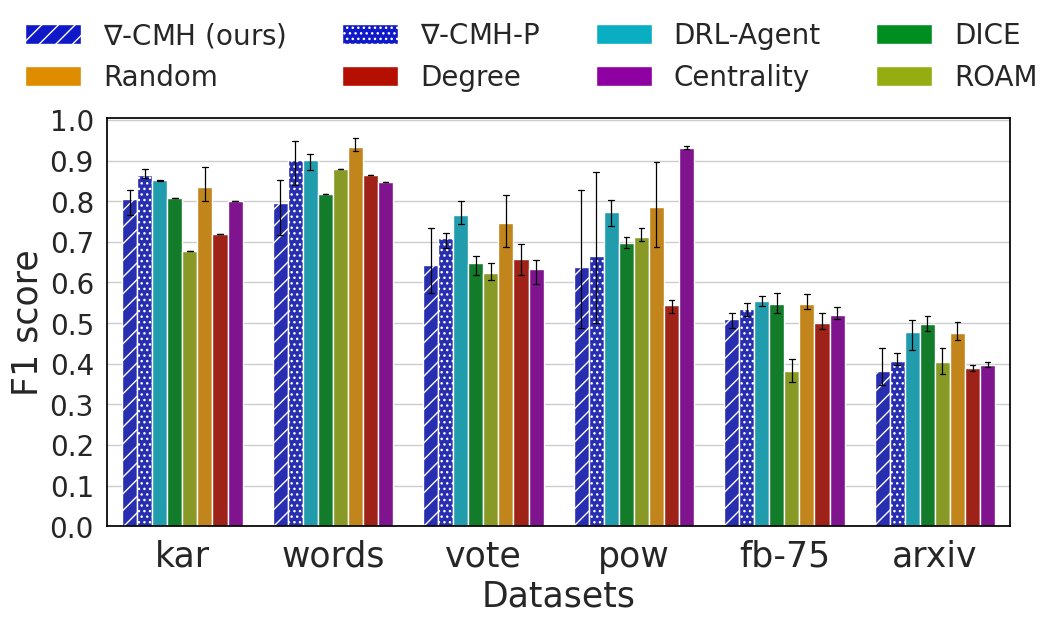

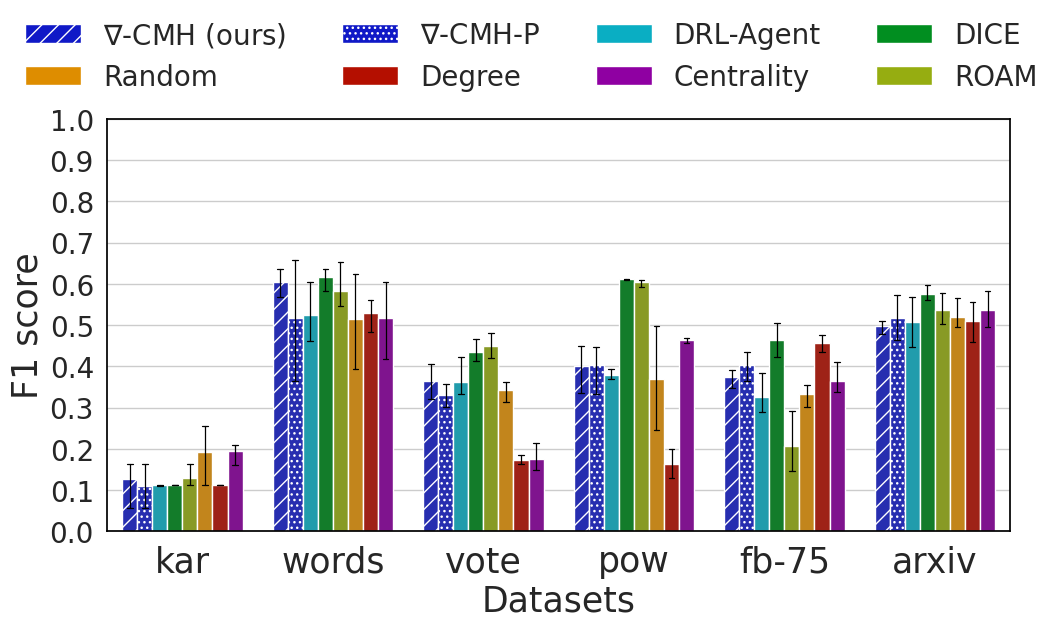

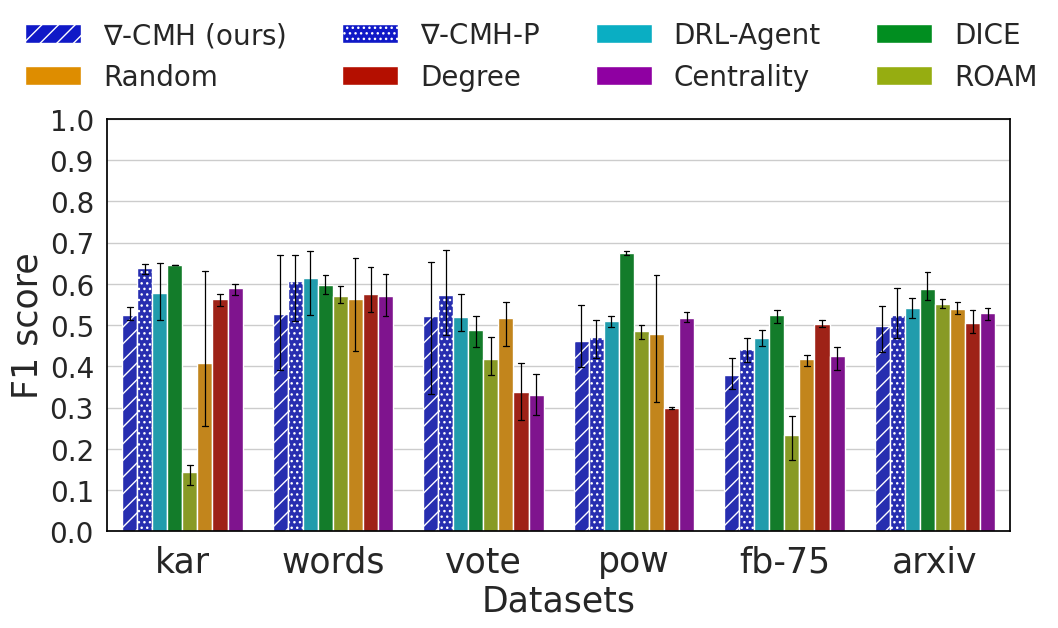

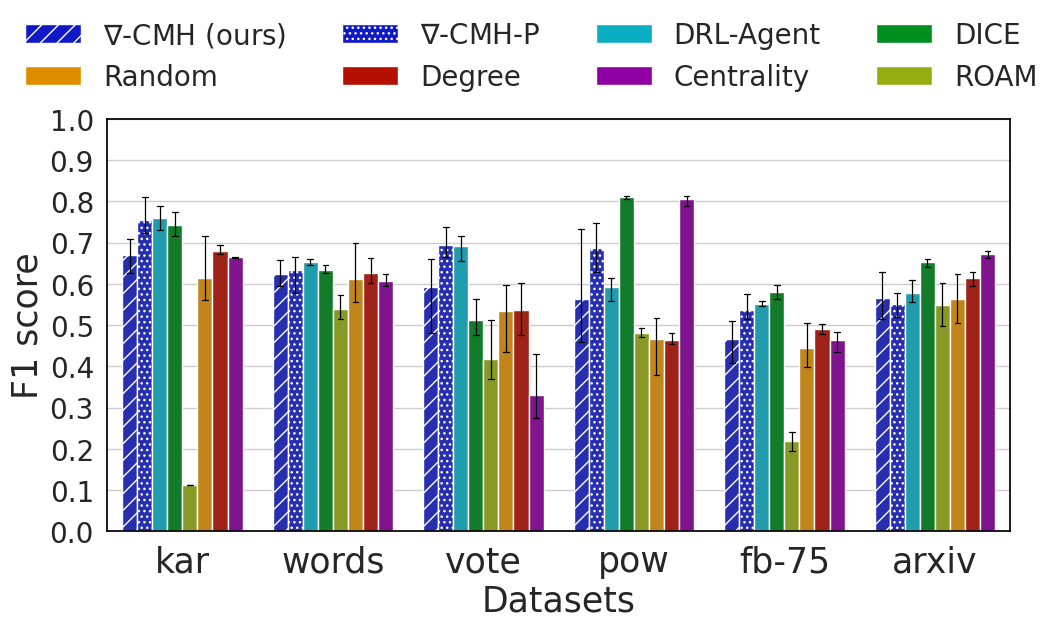

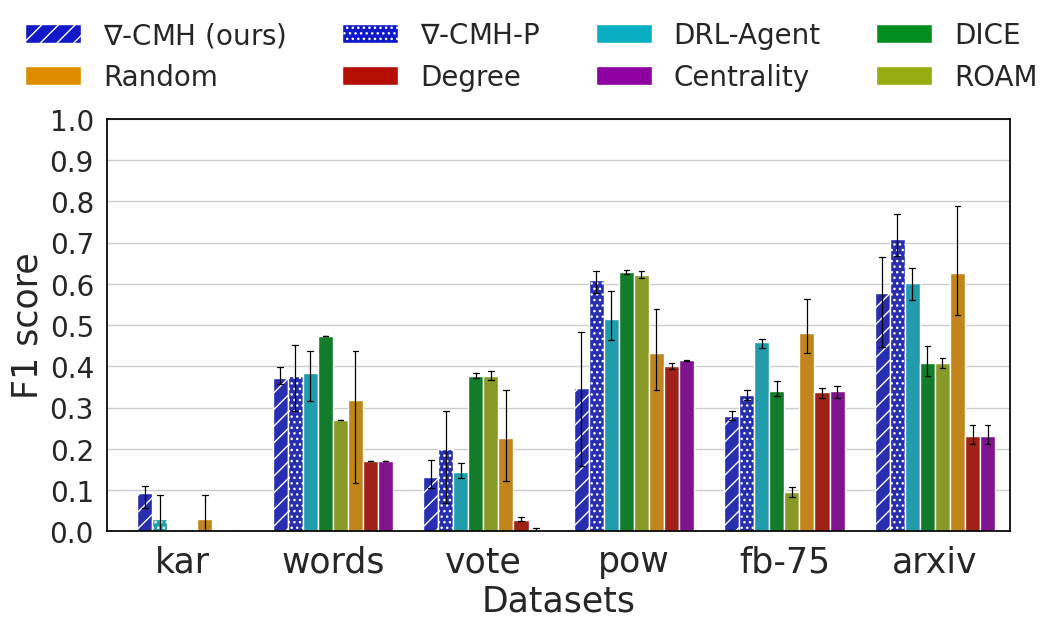

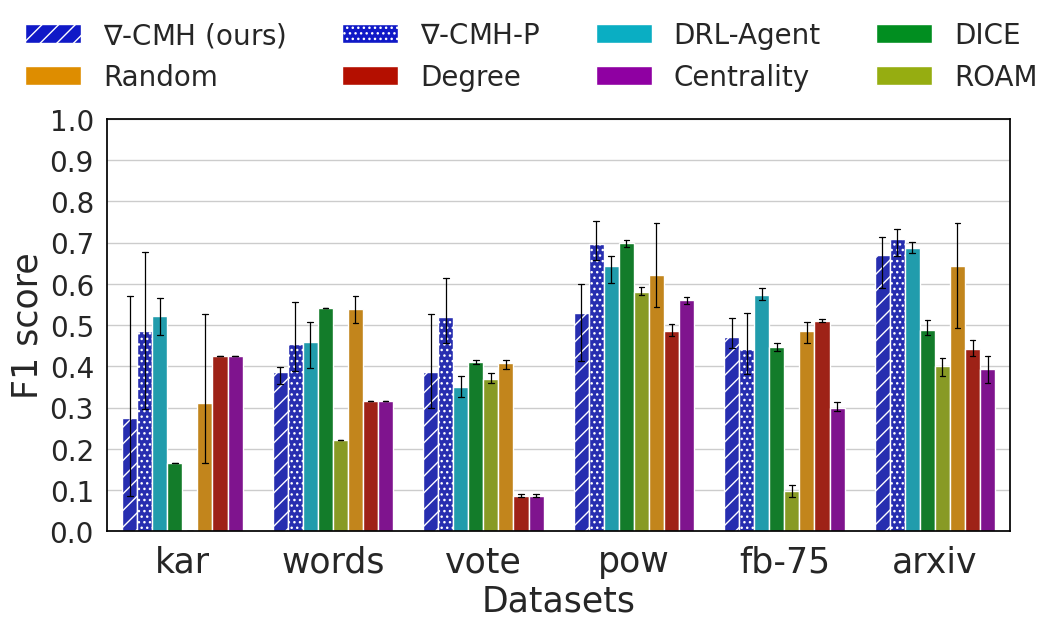

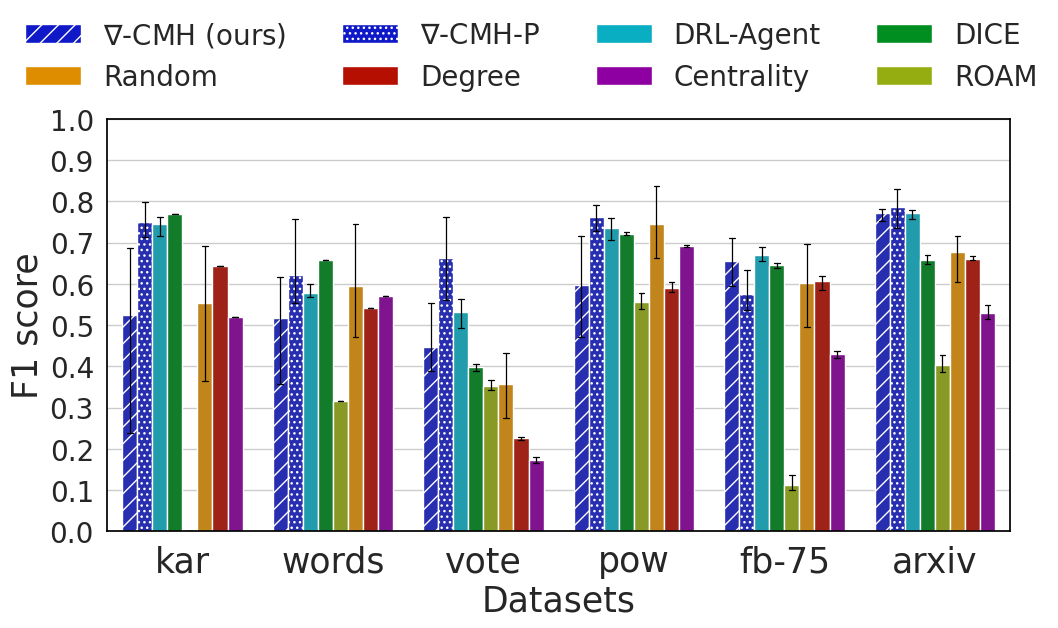

In [20]:
plot_f1_all_datasets(
    datasets= ["KAR", "WORDS", "VOTE", "POW", "FB_75", "COND_MAT"],
    #datasets= ["KAR"],
    detection_algs= ["GRE", "LOUV", "LEID", "WALK", "INF", "SCD", "LOC", "DGC"],
    #detection_algs= ["DGC"],
    seeds=[22,2025,42],
    taus=[0.5],
    betas=[0.5,1,2],
    #betas=[1],
)

## SR and NMI Plots

Same layout, palette, hatching and confidence interval as the F1 plot above, but for the two
underlying metrics shown separately: Success Rate (`goal`, stored as a percentage 0-100) and NMI.

In [ ]:
# Per-metric configuration: how to read/label/save each metric.
# - "goal" is stored in metrics.json already as a percentage (0-100) -> Success Rate (SR)
# - "nmi"  is stored as a similarity score (0-1)
# - "f1"   is the harmonic mean of goal and nmi (kept here for completeness; see plot_f1_all_datasets)
METRIC_CONFIG = {
    "f1":   {"subdir": "f1_score",     "fname": "f1_score_grouped.pdf",
             "ylabel": "F1 score",         "yticks": [i * 0.1 for i in range(0, 11)]},
    "goal": {"subdir": "success_rate", "fname": "sr_grouped.pdf",
             "ylabel": "Success Rate (%)", "yticks": [i * 10  for i in range(0, 11)]},
    "nmi":  {"subdir": "nmi",          "fname": "nmi_grouped.pdf",
             "ylabel": "NMI",              "yticks": [i * 0.1 for i in range(0, 11)]},
}


def plot_metric_all_datasets(
    metric: str,
    datasets: List[str],
    detection_algs: List[str],
    seeds: List[int],
    taus: List[float],
    betas: List[float],
    ):
    """
    Plot a single metric (Success Rate or NMI) of the evaluation on all the datasets and
    detection algorithms across all runs. This mirrors `plot_f1_all_datasets` (same layout,
    palette, hatching and confidence interval) but plots one raw metric instead of the F1.

    The confidence interval is computed exactly like in the F1 plot: for every
    (dataset, detection_alg, tau, beta, evading_alg) we collect one value per seed from
    `metrics.json` and let seaborn compute the 95% bootstrap CI over the seeds.

    Parameters
    ----------
    metric : str
        Metric to plot, one of METRIC_CONFIG keys ("goal" for Success Rate, "nmi", "f1").
    datasets : List[str]
        List of datasets
    detection_algs : List[str]
        List of detection algorithms
    seeds : List[int]
        List of seeds
    taus : List[float]
        List of tau values
    betas : List[float]
        List of beta values
    """

    cfg = METRIC_CONFIG[metric]
    save_path = f"../outputs_review/all_datasets/{cfg['subdir']}/"
    check_dir(save_path)

    dataset_names = [getattr(DatasetNames, dataset).value for dataset in datasets]
    evading_algs=["NABLA","NABLAP", "DRL","RAND","DICE","DEG","ROAM","BETW"]
    community_algs = [getattr(DetectionAlgorithmsNames, alg).value for alg in detection_algs]

    # Redefine the names of the algorithms
    nabla_renamed = r"$\nabla$-CMH (ours)"
    nablap_renamed = r"$\nabla$-CMH-P"
    agent_renamed = "DRL-Agent"
    random_renamed = "Random"
    dice_renamed = "DICE"
    deg_renamed = "Degree"
    roam_renamed = "ROAM"
    betweenness_renamed = "Centrality"

    metric_dict = {}
    for dataset in dataset_names:
        metric_dict[dataset] = {}
        for detection_alg in community_algs:
            metric_dict[dataset][detection_alg] = {}
            for tau in taus:
                metric_dict[dataset][detection_alg][f"tau_{tau}"] = {}
                for beta in betas:
                    metric_dict[dataset][detection_alg][f"tau_{tau}"][f"beta_{beta}"] = {}
                    for alg in evading_algs:
                        metric_dict[dataset][detection_alg][f"tau_{tau}"][f"beta_{beta}"][alg] = []
                        for seed in seeds:
                            json_path = f"{results_dir}/seed_{seed}/{dataset}/{detection_alg}/tau_{tau}/betaFactor_{beta}/plots/metrics.json"
                            with open(json_path, "r") as f:
                                log = json.load(f)
                            metric_dict[dataset][detection_alg][f"tau_{tau}"][f"beta_{beta}"][alg].append(log[metric][alg])


    for detection_alg in community_algs:
        for tau in taus:
            for beta in betas:
                plot_data = []
                for dataset in dataset_names:
                    df = pd.DataFrame(metric_dict[dataset][detection_alg][f"tau_{tau}"][f"beta_{beta}"])
                    plot_data.append(df)
                df = pd.concat(plot_data,axis=1)
                # Replace algorithm names in evading_algs list
                evading_algs = [
                    nabla_renamed,
                    nablap_renamed,
                    agent_renamed,
                    random_renamed,
                    dice_renamed,
                    deg_renamed,
                    roam_renamed,
                    betweenness_renamed
                ]
                # in datasets list replace "cond-mat" with "arxiv"
                datasets_renamed = ["arxiv" if dataset == "cond-mat" else dataset for dataset in dataset_names]
                df.columns = pd.MultiIndex.from_product([datasets_renamed, evading_algs])
                # Melt the dataframe
                df = df.melt(var_name=["Dataset", "Algorithm"], value_name=metric)

                # Palette personalizzata 2
                custom_palette2 = {
                    nabla_renamed: "#1019C7",
                    nablap_renamed: "#1019C7",
                    agent_renamed: "#0AAEC3", 
                    dice_renamed: "#018E20",  
                    roam_renamed: "#96AD11",  
                    random_renamed: "#DE8D00",         
                    deg_renamed: "#B40F00",              
                    betweenness_renamed: "#8F00A2"   
                }

                sns.set_theme(style="whitegrid")
                g = sns.catplot(
                    data=df,
                    kind="bar",
                    x="Dataset",
                    y=metric,
                    hue="Algorithm",
                    hue_order=[
                        r"$\nabla$-CMH (ours)", 
                        r"$\nabla$-CMH-P",
                        "DRL-Agent", 
                        "DICE", 
                        "ROAM",
                        "Random", 
                        "Degree", 
                        "Centrality", 
                    ],
                    aspect=2,
                    palette=custom_palette2,
                    errorbar=('ci', 95),
                    legend=False,
                    capsize=0.3,
                    err_kws={
                        'linewidth': .9,   
                        'color': 'black',    
                    },
                )
                ax = g.ax  
                ax.set_yticks(cfg["yticks"])
                g.set_axis_labels("Datasets", cfg["ylabel"], fontsize=25)
                g.set_yticklabels(fontsize=20)
                g.set_xticklabels(ha="center", fontsize=25)
                custom_handles = [
                    Patch(facecolor=custom_palette2[alg], label=alg, 
                        hatch=('//' if alg == '$\\nabla$-CMH (ours)' else 
                                '...' if alg == '$\\nabla$-CMH-P' else ''))
                    for alg in ['$\\nabla$-CMH (ours)', 'Random', '$\\nabla$-CMH-P', 'Degree', 'DRL-Agent', 'Centrality', 'DICE', 'ROAM']
                ]
                plt.legend(handles=custom_handles, loc='upper center', bbox_to_anchor=(0.47, 1.3), frameon=False, ncol=4, fontsize=20)
                for ax in g.axes.flat:
                    ax.spines["top"].set_visible(True)
                    ax.spines["right"].set_visible(True)
                    ax.spines["top"].set_color("black")
                    ax.spines["right"].set_color("black")
                    ax.spines["left"].set_color("black")
                    ax.spines["bottom"].set_color("black")
                indices_to_hatch_lines = [0,1,2,3,4,5]
                indices_to_hatch_reversed = [6,7,8,9,10,11] 
                for ax in g.axes.flat:  
                    bars = ax.patches  
                    bars = [bar for bar in ax.patches if bar.get_height() > 0]
                    for i, bar in enumerate(bars):  
                        if i in indices_to_hatch_lines:  
                            bar.set_hatch('//')  
                        elif i in indices_to_hatch_reversed:
                            bar.set_hatch('...')


                save_fig_path = f"{save_path}/{detection_alg}/tau_{tau}/beta_{beta}"
                check_dir(save_fig_path)
                g.savefig(
                    f"{save_fig_path}/{cfg['fname']}",
                    bbox_inches="tight",
                    dpi=1000,
                )

## SR and NMI Plot Function calls

In [ ]:
# Success Rate (SR) plot
plot_metric_all_datasets(
    metric="goal",
    datasets= ["KAR", "WORDS", "VOTE", "POW", "FB_75", "COND_MAT"],
    detection_algs= ["GRE", "LOUV", "LEID", "WALK", "INF", "SCD", "LOC", "DGC"],
    seeds=[22,2025,42],
    taus=[0.5],
    betas=[0.5,1,2],
)

# NMI plot
plot_metric_all_datasets(
    metric="nmi",
    datasets= ["KAR", "WORDS", "VOTE", "POW", "FB_75", "COND_MAT"],
    detection_algs= ["GRE", "LOUV", "LEID", "WALK", "INF", "SCD", "LOC", "DGC"],
    seeds=[22,2025,42],
    taus=[0.5],
    betas=[0.5,1,2],
)

## Radar plot of promising actions' coefficient

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append("../")
from src.methods.nabla_cmh.config import HYPERPARAMETERS
import numpy as np

labels = ['Centrality', 'Degree', 'Intra-degree', 'Inter-degree']
num_vars = len(labels)
training_alg = "greedy"
tau = 0.5
beta = 1

coefficients = {
    "kar": HYPERPARAMETERS["kar"][f"training_{training_alg}"]["tau_0.5"]["betaFactor_1"]["promising_action_coeffs"][:4],
    "words": HYPERPARAMETERS["words"][f"training_{training_alg}"]["tau_0.5"]["betaFactor_1"]["promising_action_coeffs"][:4],
    "vote": HYPERPARAMETERS["vote"][f"training_{training_alg}"]["tau_0.5"]["betaFactor_1"]["promising_action_coeffs"][:4],
    "pow": HYPERPARAMETERS["pow"][f"training_{training_alg}"]["tau_0.5"]["betaFactor_1"]["promising_action_coeffs"][:4],
    "fb-75": HYPERPARAMETERS["fb-75"][f"training_{training_alg}"]["tau_0.5"]["betaFactor_1"]["promising_action_coeffs"][:4],
    "arxiv": HYPERPARAMETERS["cond-mat"][f"training_{training_alg}"]["tau_0.5"]["betaFactor_1"]["promising_action_coeffs"][:4],
}

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

colors = ['#1019C7', '#0AAEC3', '#018E20', '#DE8D00', '#B40F00', '#8F00A2']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (name, values) in enumerate(coefficients.items()):
    values_plot = list(values) + [values[0]]
    ax.plot(angles, values_plot, label=name, linewidth=1.5, marker='o', color=colors[i])
    ax.fill(angles, values_plot, alpha=0.1, color=colors[i])

# Asse e limiti
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=16, fontweight='bold')
ax.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
ax.set_yticklabels(['0.2', '0.3','0.4', '0.5', '0.6','0.7'], color='gray')
for label in ax.get_yticklabels():
    label.set_zorder(3)

ax.set_rlabel_position(45)
ax.set_ylim(0, 0.7)

fig.patch.set_facecolor('white')
ax.patch.set_facecolor('white')
ax.yaxis.grid(True, linestyle='--', linewidth=0.8, color='lightgray')

xtick_labels = ax.get_xticklabels()

xtick_labels[0].set_horizontalalignment('left')
xtick_labels[2].set_horizontalalignment('right')



plt.legend(loc='upper left', bbox_to_anchor=(-0.42, 1.1), fontsize=12)
plt.tight_layout()
plt.savefig(
    f"../outputs_review/all_datasets/promising_actions_coeffs.pdf",
    bbox_inches="tight",
    dpi=200,
)


## Visualizing impact of perturbation across methods

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import itertools

# Carica i dati da file JSON
with open("../outputs_review/all_datasets/impact.json", "r") as f:
    data = json.load(f)

datasets = list(data.keys())
metodi = ['NABLA', 'DRL', 'DICE', 'ROAM', 'RAND', 'DEG', 'BETW']

# Marker e colori dinamici
marker_cycle = itertools.cycle(['o', 's', 'D', '^', 'v', '*'])
# Palette personalizzata 2
custom_palette2 = {
    '$\\nabla$-CMH (ours)': "#1019C7",  
    'DRL-Agent': "#0AAEC3", 
    'DICE': "#018E20",  
    'ROAM': "#96AD11",  
    'Random': "#DE8D00",         
    'Degree': "#B40F00",              
    'Centrality': "#8F00A2"   
}
color_cycle = itertools.cycle(custom_palette2.values())

plt.figure(figsize=(10, 6))

# Offset per separare i punti per metodo
x = np.arange(len(datasets))
offset = np.linspace(-0.1, 0.1, len(metodi))

for i, metodo in enumerate(metodi):
    valori = [data[ds][metodo]["mean"] for ds in datasets]
    stds = [data[ds][metodo]["std"] for ds in datasets]
    marker = next(marker_cycle)
    color = next(color_cycle)
    
    plt.errorbar(
        x + offset[i], valori, yerr=stds, fmt=marker,
        label=metodo, color=color, capsize=3, linestyle='none', markersize=6
    )

plt.yscale("log")
datasets_label = ["arxiv" if ds == "cond-mat" else ds for ds in datasets]
plt.xticks(x, datasets_label, fontsize=20)
plt.ylabel("PageRank impact (log scale)", fontsize=20)
custom_handles = [
    Patch(facecolor=custom_palette2[alg], label=alg)
    for alg in ['$\\nabla$-CMH (ours)', 'Random', 'DRL-Agent', 'Degree',  'DICE', 'Centrality',  'ROAM' ]
]
plt.legend(handles=custom_handles, loc='upper center', bbox_to_anchor=(0.47, 1.3), frameon=False, ncol=4, fontsize=15)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


## Heatmap

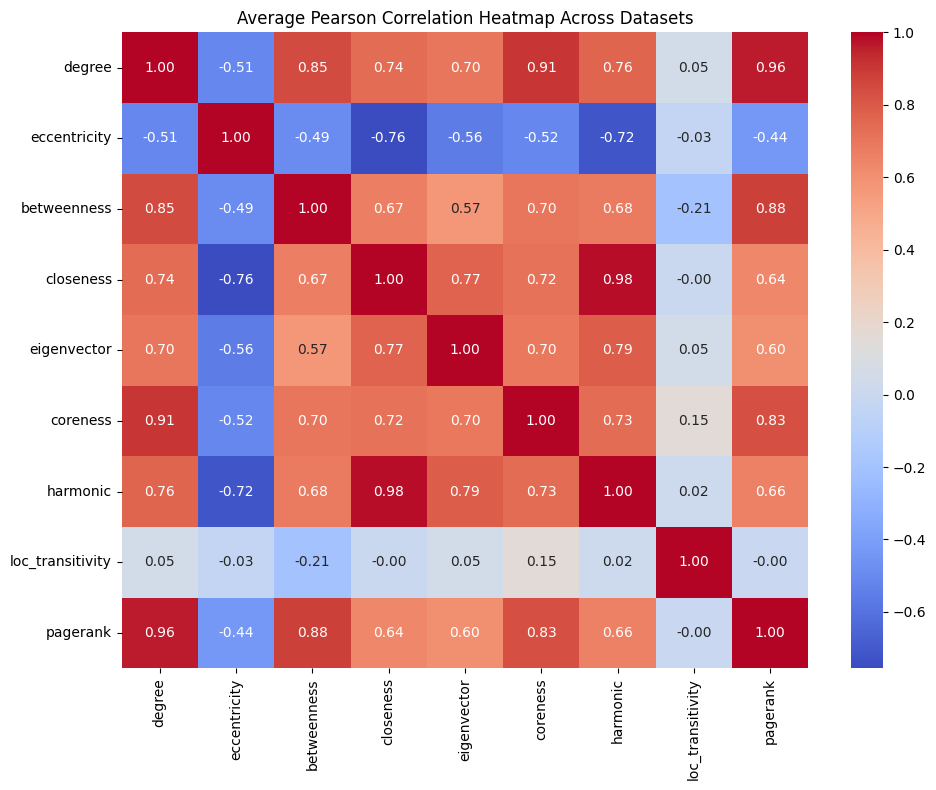

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Lista dei dataset (modifica se necessario)
datasets = ["kar", "words", "vote", "pow", "fb-75", "cond-mat"]

# Percorso base dove sono salvate le matrici
base_path = "../outputs_review/feature_analysis"

# Lista per accumulare le matrici di correlazione
corr_matrices = []

type = "spearman"

for dataset in datasets:
    path = f"{base_path}/{dataset}/{dataset}_{type}_corr.csv"
    corr = pd.read_csv(path, index_col=0)
    corr_matrices.append(corr)

# Calcola la media delle matrici
mean_corr = sum(corr_matrices) / len(corr_matrices)

# Visualizza la heatmap della media
plt.figure(figsize=(10, 8))
sns.heatmap(mean_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Average Pearson Correlation Heatmap Across Datasets")
plt.tight_layout()
plt.savefig(f"{base_path}/average_{type}_corr.png")

# (Opzionale) Salva la matrice media come CSV
mean_corr.to_csv(f"{base_path}/average_{type}_corr.csv")